## 12.1 Understand Important Signals

The Random Forest feature importance analysis shows that historical search-performance signals contribute most strongly to the model's predictions.

The most important feature is `historical_mean_position`, followed by `historical_impressions_per_day` and `historical_impressions`.

Content-level features such as `word_count`, `char_count`, `search_volume`, `competition`, and `backlinks` contribute smaller individual shares of importance.

This indicates that the model relies primarily on historical search visibility and search-position signals when estimating future content opportunity.

The importance values describe how the trained model uses the available features. They do not represent Google's ranking algorithm and should not be interpreted as evidence of Google's ranking factors.

These results are observational and model-based. They indicate associations within this dataset rather than causal effects.

## Model

|   K | Precision | Recall |   NDCG |
| --: | --------: | -----: | -----: |
|  10 |      0.50 |   0.50 | 0.9831 |
|  25 |      0.64 |   0.64 | 0.9701 |
|  50 |      0.56 |   0.56 | 0.9694 |
| 100 |      0.55 |   0.55 | 0.9693 |


## Historical Impressions Baseline

|   K | Precision | Recall |   NDCG |
| --: | --------: | -----: | -----: |
|  10 |      0.00 |   0.00 | 0.7496 |
|  25 |      0.04 |   0.04 | 0.7707 |
|  50 |      0.06 |   0.06 | 0.7924 |
| 100 |      0.09 |   0.09 | 0.8073 |


## Historical Clicks Baseline

|   K | Precision | Recall |   NDCG |
| --: | --------: | -----: | -----: |
|  10 |      0.00 |   0.00 | 0.7486 |
|  25 |      0.00 |   0.00 | 0.7393 |
|  50 |      0.00 |   0.00 | 0.7488 |
| 100 |      0.00 |   0.00 | 0.7604 |


## Historical Position Baseline

|   K | Precision | Recall |   NDCG |
| --: | --------: | -----: | -----: |
|  10 |      0.00 |   0.00 | 0.5168 |
|  25 |      0.00 |   0.00 | 0.5292 |
|  50 |      0.00 |   0.00 | 0.5471 |
| 100 |      0.00 |   0.00 | 0.5626 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
comparison = pd.DataFrame({
    'K': [10, 25, 50, 100],
    'Model_NDCG': [0.983057, 0.970115, 0.969419, 0.969281],
    'Impressions_Baseline_NDCG': [0.749582, 0.770668, 0.792397, 0.807323],
    'Clicks_Baseline_NDCG': [0.748636, 0.739255, 0.748774, 0.760355],
    'Position_Baseline_NDCG': [0.516845, 0.529164, 0.547108, 0.562596]
})

comparison['Improvement_vs_Impressions'] = (
    comparison['Model_NDCG']
    - comparison['Impressions_Baseline_NDCG']
)

comparison['Relative_Improvement_vs_Impressions'] = (
    comparison['Improvement_vs_Impressions']
    / comparison['Impressions_Baseline_NDCG']
    * 100
)

comparison

,K,Model_NDCG,Impressions_Baseline_NDCG,Clicks_Baseline_NDCG,Position_Baseline_NDCG,Improvement_vs_Impressions,Relative_Improvement_vs_Impressions
0,10,0.983057,0.749582,0.748636,0.516845,0.233475,31.147359
1,25,0.970115,0.770668,0.739255,0.529164,0.199447,25.879756
2,50,0.969419,0.792397,0.748774,0.547108,0.177022,22.340064
3,100,0.969281,0.807323,0.760355,0.562596,0.161958,20.061116


### Model vs Baseline Findings

The Random Forest model was compared with simple historical-performance baselines using the same evaluation data and ranking metrics.

The model achieved an NDCG@100 of approximately 0.969, compared with approximately 0.807 for the historical-impressions baseline.

This represents an absolute improvement of approximately 0.162 NDCG points, or about 20.1% relative to the historical-impressions baseline.

The model also consistently achieved higher NDCG values than the historical-clicks and historical-position baselines across the evaluated cutoff values.

These results indicate that the model produced rankings that were more aligned with the defined future opportunity benchmark than the tested simple baselines.

However, this improvement should not be interpreted as proof that the model will cause better SEO performance or that the prioritized content will actually improve after optimization.

The evaluation target is a constructed future opportunity benchmark rather than a ground-truth label for successful content optimization.

## 12.1 Model Performance

The Random Forest model was evaluated using ranking metrics at different top-K cutoffs.

The evaluation focuses on Precision@K, Recall@K, and NDCG@K.

In [3]:
model_results = pd.DataFrame({
    'K': [10, 25, 50, 100],
    'Precision': [0.50, 0.64, 0.56, 0.55],
    'Recall': [0.50, 0.64, 0.56, 0.55],
    'NDCG': [0.983057, 0.970115, 0.969419, 0.969281]
})

model_results

,K,Precision,Recall,NDCG
0,10,0.50,0.50,0.983057
1,25,0.64,0.64,0.970115
2,50,0.56,0.56,0.969419
3,100,0.55,0.55,0.969281


## 12.2 Important Signals

The model's feature importance analysis shows which input features contributed most strongly to the Random Forest predictions.

These values describe model behavior and should not be interpreted as causal effects or as evidence of Google's ranking algorithm.

In [4]:
feature_importance = pd.DataFrame({
    'Feature': [
        'historical_mean_position',
        'historical_impressions_per_day',
        'historical_impressions',
        'word_count',
        'char_count',
        'historical_ctr',
        'search_volume',
        'competition',
        'category_count',
        'backlinks',
        'cpc',
        'main_intent',
        'historical_reporting_days',
        'historical_clicks_per_day',
        'historical_clicks',
        'competition_level',
        'content_type'
    ],
    'Importance': [
        0.677796,
        0.161989,
        0.085737,
        0.014936,
        0.014812,
        0.011334,
        0.007251,
        0.005609,
        0.004424,
        0.003817,
        0.003091,
        0.002501,
        0.002281,
        0.002136,
        0.001650,
        0.000608,
        0.000029
    ]
})

feature_importance

,Feature,Importance
0,historical_mean_position,0.677796
1,historical_impressions_per_day,0.161989
2,historical_impressions,0.085737
3,word_count,0.014936
4,char_count,0.014812
5,historical_ctr,0.011334
6,search_volume,0.007251
7,competition,0.005609
8,category_count,0.004424
9,backlinks,0.003817


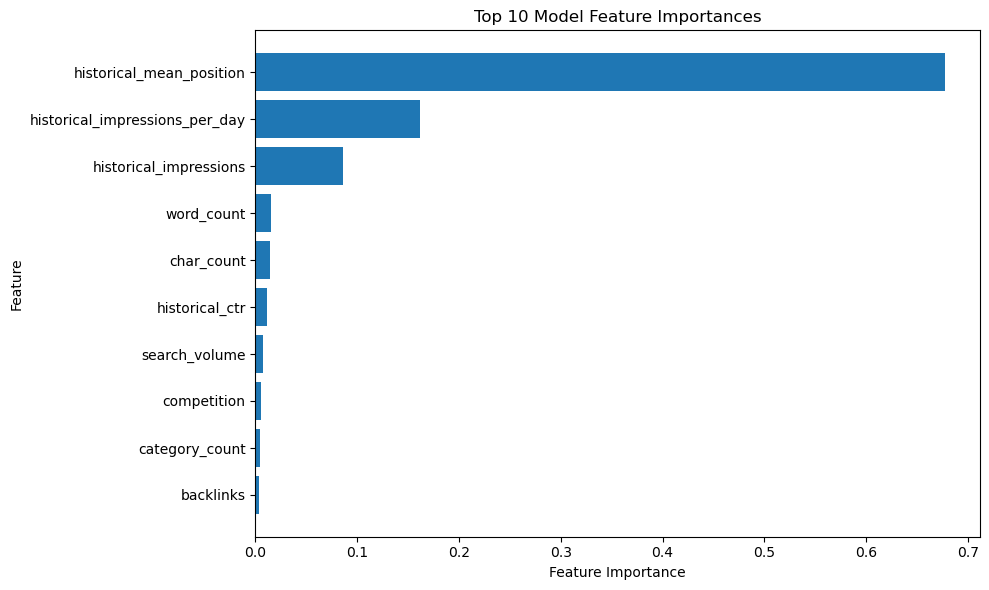

In [5]:
top_features = feature_importance.head(10).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Model Feature Importances')
plt.tight_layout()
plt.show()

## 12.3 Model vs Baseline

The model is compared with three simple historical-performance baselines:

- Historical impressions
- Historical clicks
- Historical position

All methods are evaluated on the same evaluation data using the same ranking cutoffs.

In [6]:
comparison = pd.DataFrame({
    'K': [10, 25, 50, 100],
    'Model_NDCG': [
        0.983057,
        0.970115,
        0.969419,
        0.969281
    ],
    'Impressions_Baseline_NDCG': [
        0.749582,
        0.770668,
        0.792397,
        0.807323
    ],
    'Clicks_Baseline_NDCG': [
        0.748636,
        0.739255,
        0.748774,
        0.760355
    ],
    'Position_Baseline_NDCG': [
        0.516845,
        0.529164,
        0.547108,
        0.562596
    ]
})

comparison

,K,Model_NDCG,Impressions_Baseline_NDCG,Clicks_Baseline_NDCG,Position_Baseline_NDCG
0,10,0.983057,0.749582,0.748636,0.516845
1,25,0.970115,0.770668,0.739255,0.529164
2,50,0.969419,0.792397,0.748774,0.547108
3,100,0.969281,0.807323,0.760355,0.562596


In [7]:
comparison['Absolute_Improvement_vs_Impressions'] = (
    comparison['Model_NDCG']
    - comparison['Impressions_Baseline_NDCG']
)

comparison['Relative_Improvement_vs_Impressions_%'] = (
    comparison['Absolute_Improvement_vs_Impressions']
    / comparison['Impressions_Baseline_NDCG']
    * 100
)

comparison

,K,Model_NDCG,Impressions_Baseline_NDCG,Clicks_Baseline_NDCG,Position_Baseline_NDCG,Absolute_Improvement_vs_Impressions,Relative_Improvement_vs_Impressions_%
0,10,0.983057,0.749582,0.748636,0.516845,0.233475,31.147359
1,25,0.970115,0.770668,0.739255,0.529164,0.199447,25.879756
2,50,0.969419,0.792397,0.748774,0.547108,0.177022,22.340064
3,100,0.969281,0.807323,0.760355,0.562596,0.161958,20.061116


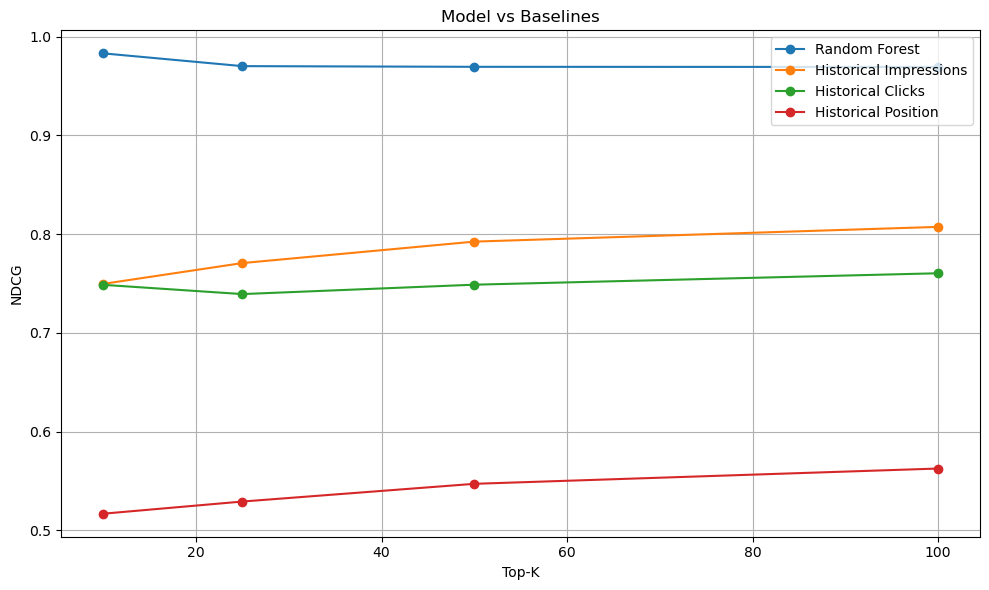

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    comparison['K'],
    comparison['Model_NDCG'],
    marker='o',
    label='Random Forest'
)

plt.plot(
    comparison['K'],
    comparison['Impressions_Baseline_NDCG'],
    marker='o',
    label='Historical Impressions'
)

plt.plot(
    comparison['K'],
    comparison['Clicks_Baseline_NDCG'],
    marker='o',
    label='Historical Clicks'
)

plt.plot(
    comparison['K'],
    comparison['Position_Baseline_NDCG'],
    marker='o',
    label='Historical Position'
)

plt.xlabel('Top-K')
plt.ylabel('NDCG')
plt.title('Model vs Baselines')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Model vs Baseline Findings

The Random Forest model was compared with three simple historical-performance baselines using the same evaluation data and ranking metrics.

The model achieved higher NDCG values than all three baselines across the evaluated top-K cutoffs.

At K=100, the model achieved an NDCG of approximately 0.969, while the historical-impressions baseline achieved approximately 0.807.

This represents an absolute improvement of approximately 0.162 NDCG points, equivalent to approximately 20.1% relative improvement compared with the historical-impressions baseline.

The model also showed higher NDCG than the historical-clicks and historical-position baselines.

These results indicate that the model's ranking was more aligned with the defined future opportunity benchmark than the tested simple baselines.

The comparison does not demonstrate that the model causes better SEO performance. The evaluation target is a constructed future opportunity benchmark rather than a confirmed label for successful content optimization.

### Important Signals Findings

The feature importance analysis shows that historical search-performance signals dominate the model's predictions.

`historical_mean_position` is the most important feature, followed by `historical_impressions_per_day` and `historical_impressions`.

Together, these three features account for approximately 92.0% of the total feature importance.

Content-level features such as `word_count`, `char_count`, `search_volume`, `competition`, and `backlinks` contribute smaller individual shares.

This suggests that the model primarily distinguishes content opportunity using historical search visibility and position signals, while content characteristics provide additional supporting information.

Feature importance describes how the trained model uses the available features. It does not establish causal relationships and should not be interpreted as evidence of Google's ranking algorithm.

## 12.4 Interpretation Limitations

Several limitations should be considered when interpreting these results.

1. The future opportunity score is a constructed benchmark rather than a ground-truth label for successful content optimization.

2. Feature importance describes model behavior and does not establish that an important feature causes future search performance.

3. The strong importance of `historical_mean_position` should be interpreted carefully because position-related information is also part of the future opportunity benchmark definition.

4. The model evaluation uses a temporal feature/evaluation design, but the supervised train-test assessment uses an 80/20 split within the modeling dataset rather than full temporal cross-validation.

5. The results are based on the available sample and evaluation period and may not generalize to other periods or datasets.

6. Reason codes are descriptive rules based on observable signals and should not be treated as direct explanations of individual Random Forest predictions.

# Phase 12 Conclusion

The interpretation analysis identified the main signals used by the Random Forest model and compared its ranking performance with simple historical-performance baselines.

Historical search-position and visibility-related features were the strongest model signals. In particular, `historical_mean_position`, `historical_impressions_per_day`, and `historical_impressions` accounted for approximately 92.0% of the total feature importance.

The Random Forest model also achieved higher NDCG values than the tested baseline approaches across the evaluated top-K cutoffs.

At K=100, the model achieved an NDCG of approximately 0.969 compared with approximately 0.807 for the historical-impressions baseline. This corresponds to an absolute improvement of approximately 0.162 NDCG points, or approximately 20.1% relative improvement.

These results indicate that the model provides a stronger ranking alignment with the defined future opportunity benchmark than the tested simple baselines.

However, the results should not be interpreted as proof of causal SEO improvement or as evidence of Google's ranking factors. The future opportunity score is a constructed benchmark rather than a confirmed optimization-success label.

The model should therefore be treated as a decision-support and prioritization tool for identifying content items that may deserve further review.

## Phase 12 Self-Check

### Task 12.1 — Understand Important Signals

- [x] I identified important features/signals.
- [x] I used an appropriate interpretation method.
- [x] I understand what the interpretation actually tells me.
- [x] I did not describe model importance as proof of Google's ranking algorithm.
- [x] Claims are framed as observed, measured, or associated.

### Task 12.2 — Model vs Baseline

- [x] Model performance is directly compared with the baseline.
- [x] The comparison uses the same evaluation data.
- [x] Improvement is quantified.
- [x] The improvement is interpreted carefully.
- [x] Limitations are documented.